### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

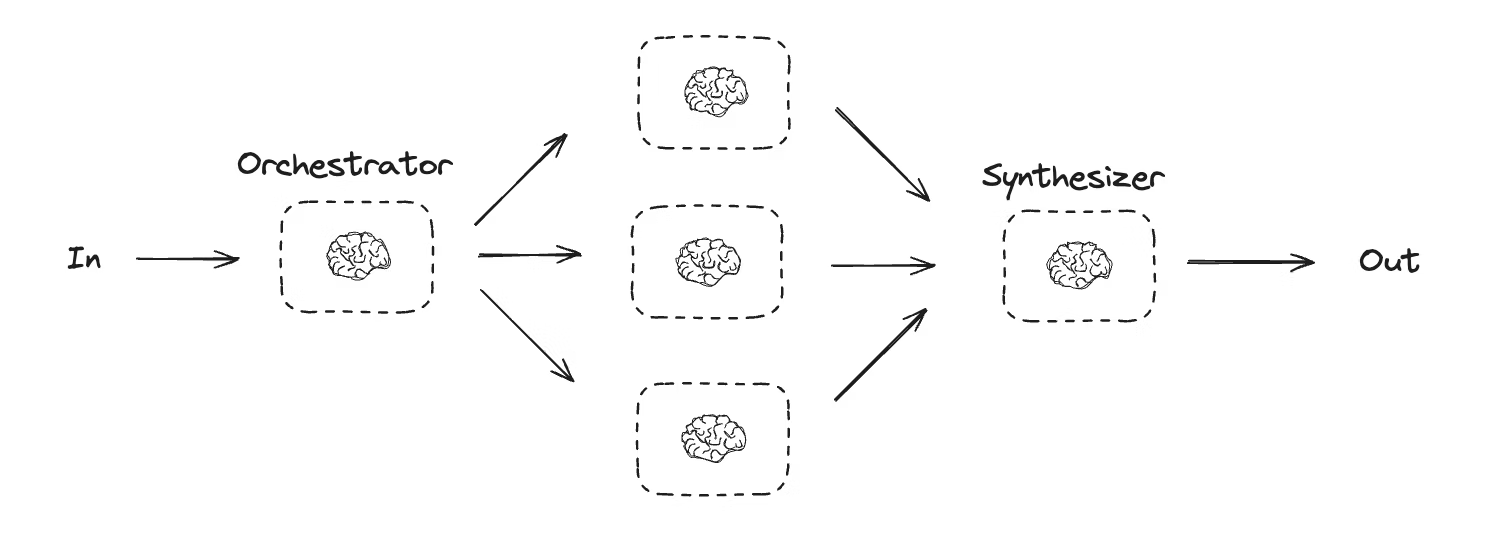

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

In [3]:
from typing import Annotated, List
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict

In [4]:
class Section(BaseModel):
    name: str=Field(description="Name for this section of the report")
    description: str=Field(description="Brief overview of main topics and concepts of the section")

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report"
    )

# Augment the LLM with schema for structured output
planner = llm_groq.with_structured_output(Sections)

### Creating workers, Dynamically in LangGraph

Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [5]:
from langgraph.types import Send
import operator

# Graph State
class State(TypedDict):
    topic: str # Report topic
    sections: list[Section] # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]
    # All workers write to this key in parallel
    final_report: str  # Final report

# Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [10]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm_groq.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


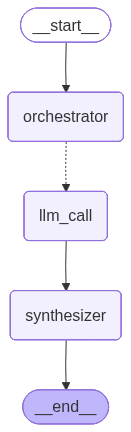

In [11]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build Workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [12]:
# Invoke
from IPython.display import Markdown

state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction', description='Overview of Agentic AI RAGs, including their purpose, key concepts, and significance in modern AI applications.'), Section(name='Core Concepts', description='Explanation of fundamental principles such as Retrieval-Augmented Generation (RAG), agentic behavior, and how they intersect.'), Section(name='Architectural Components', description='Breakdown of key system components, including retrieval mechanisms, generative models, and decision-making frameworks.'), Section(name='Applications and Use Cases', description='Analysis of real-world applications, such as personalized assistants, autonomous decision systems, and dynamic content generation.'), Section(name='Challenges and Limitations', description='Discussion of current limitations, including data dependency, ethical concerns, and scalability issues.'), Section(name='Future Directions', description='Speculation on emerging trends, research opportunities, and potentia

# Introduction and Description: Overview of Agentic AI RAGs  

Agentic AI RAGs (Retrieval-Augmented Generation systems with autonomous agency) represent a transformative approach in artificial intelligence, blending large language models (LLMs) with dynamic knowledge retrieval and decision-making frameworks. These systems are designed to autonomously retrieve, analyze, and synthesize information from diverse data sources to generate contextually relevant responses or actions. Unlike traditional static models, Agentic AI RAGs integrate continuous learning, adaptive reasoning, and goal-directed behavior, enabling them to operate effectively in complex, real-world scenarios.  

## Purpose  
The primary purpose of Agentic AI RAGs is to bridge the gap between rigid, pre-trained models and the fluid demands of modern applications. By leveraging external knowledge bases and real-time data retrieval, they enhance accuracy, reduce hallucinations, and improve contextual relevance. Their agentic capabilities allow them to prioritize tasks, manage workflows, and interact with users or systems in a purpose-driven manner, making them ideal for applications requiring both depth and adaptability.  

## Key Concepts  
1. **Retrieval-Augmented Generation (RAG):** Combines retrieval of external knowledge with generative models to produce informed outputs.  
2. **Autonomous Agency:** Enables systems to make decisions, delegate subtasks, and adapt strategies without explicit human intervention.  
3. **Dynamic Knowledge Integration:** Continuously updates internal representations using real-time or user-specific data sources.  
4. **Iterative Refinement:** Refines outputs through multiple cycles of retrieval, analysis, and generation to ensure precision and coherence.  

## Significance in Modern AI Applications  
Agentic AI RAGs are pivotal in domains demanding high stakes and nuanced understanding, such as healthcare diagnostics, legal research, and personalized education. Their ability to balance factual accuracy with contextual creativity addresses critical limitations of conventional AI systems. Additionally, they foster transparency by tracing outputs back to verifiable sources, thereby enhancing trust and compliance. As organizations prioritize scalable, reliable AI solutions, Agentic AI RAGs stand out as a cornerstone for advancing intelligent automation and human-AI collaboration.

---

# Core Concepts

## Retrieval-Augmented Generation (RAG)
Retrieval-Augmented Generation (RAG) is a hybrid framework that integrates information retrieval (IR) with generative models to enhance the accuracy and relevance of responses. In RAG, a model retrieves contextually relevant documents from a database or corpus using a retrieval component (e.g., a dense vector search engine) and then generates a response by conditioning on both the input query and the retrieved documents. This approach bridges the gap between static, pre-trained knowledge in models and dynamic, up-to-date external information, reducing hallucinations and improving factual consistency.

## Agentic Behavior
Agentic behavior refers to the capacity of autonomous systems to perceive, reason, and act on their environment while pursuing specific goals. In AI, agentic systems exhibit traits such as goal-setting, planning, decision-making, and adaptability. These systems often operate in iterative loops: they observe their environment, formulate plans, execute actions, and update their strategies based on feedback. Agentic behavior is critical in tasks requiring autonomy, such as complex problem-solving, interactive dialogue, or dynamic environments like robotics or game-playing agents.

## Intersection of RAG and Agentic Behavior
The integration of RAG and agentic behavior enables systems to dynamically access external knowledge while autonomously navigating tasks. For example, an agentic AI using RAG can retrieve real-time data to inform decisions, ensuring actions are grounded in both pre-existing knowledge and current context. This synergy is particularly valuable in applications like research assistants, customer service agents, or recommendation systems, where adaptability and access to accurate, up-to-date information are paramount. RAG provides the "memory" for informed decision-making, while agentic behavior drives proactive task execution and environmental interaction.

---

## Architectural Components

### Retrieval Mechanisms  
The system employs **vector-based retrieval** to access domain-specific knowledge. This includes:  
- **Vector databases** storing embeddings of documents, FAQs, or user interactions.  
- **Similarity search** algorithms (e.g., FAISS or approximate nearest neighbors) to identify relevant data.  
- **Query processing pipelines** that normalize inputs, filter noise, and prioritize contextually relevant results.  
- **Hybrid retrieval** combining keyword matching and semantic similarity for robustness.  

### Generative Models  
The generative layer synthesizes responses using **transformer-based architectures**:  
- **Pre-trained language models** (e.g., LLMs) fine-tuned for domain-specific tasks.  
- **Prompt engineering** techniques to align outputs with user intent (e.g., role-based prompts or chain-of-thought reasoning).  
- **Output filtering** to ensure safety, coherence, and adherence to guidelines.  
- **Real-time adaptation** via in-context learning to incorporate retrieval results dynamically.  

### Decision-Making Frameworks  
The system integrates **rule-based and probabilistic logic** for decision-making:  
- **Rule engines** enforcing constraints (e.g., compliance checks, access controls).  
- **Reinforcement learning** models optimizing for user satisfaction or operational efficiency.  
- **Multi-agent coordination** in distributed systems, using consensus algorithms or federated learning.  
- **Feedback loops** to refine decisions iteratively using A/B testing or user ratings.  

Components are modular, enabling independent updates while maintaining interoperability through standardized APIs.

---

### Applications and Use Cases  

#### Personalized Assistants  
Personalized assistants, such as virtual voice assistants (e.g., Siri, Alexa) and chatbots (e.g., customer service bots), leverage natural language processing (NLP) and machine learning (ML) to adapt to user preferences and behaviors. These systems are widely used in smart homes, mobile devices, and enterprise platforms to streamline tasks like scheduling, information retrieval, and device control. Key benefits include **improved user efficiency** and **24/7 availability**, but challenges such as **privacy concerns**, **accuracy in multilingual contexts**, and **over-reliance on training data** persist. For instance, voice assistants may struggle with regional accents or dialects, and chatbots often face criticism for inadequate contextual understanding in complex interactions.  

#### Autonomous Decision Systems  
Autonomous decision systems, powered by AI and real-time data analytics, are deployed in sectors like finance (algorithmic trading), healthcare (diagnostic tools), and logistics (predictive maintenance). These systems optimize outcomes by analyzing vast datasets to make rapid, data-driven choices. For example, in healthcare, AI-driven diagnostic models reduce human error and expedite early disease detection. However, ethical dilemmas (e.g., bias in automated lending systems) and the "black box" nature of AI algorithms hinder transparency. Additionally, the reliance on high-quality, representative data remains a critical barrier to adoption, particularly in industries with fragmented or outdated data infrastructure.  

#### Dynamic Content Generation  
Dynamic content generation involves AI-driven creation of text, images, or videos tailored to user preferences or contextual needs. Applications include **personalized marketing campaigns**, **automated news briefings**, and **interactive gaming narratives**. Generative models like GPT and DALL·E enable businesses to produce scalable, on-demand content, reducing manual labor and costs. For instance, e-commerce platforms use AI to generate product descriptions that align with specific audience segments. However, challenges such as **content originality**, **ethical risks (e.g., deepfakes)**, and **quality consistency** remain unresolved. Over-reliance on these systems may also dilute human creativity and authenticity in creative industries.  

#### Cross-Application Impact  
The integration of these applications often yields synergistic benefits. For example, personalized assistants may utilize dynamic content generation to deliver real-time, tailored responses. Autonomous decision systems can enhance smart home environments by coordinating with voice assistants to optimize energy usage. However, such interdependencies amplify risks like cascading failures or data silos. Organizations must balance innovation with robust governance frameworks to ensure reliability, fairness, and user trust.

---

### Challenges and Limitations  

#### Data Dependency  
AI systems rely heavily on high-quality, representative datasets for training, which can be difficult to obtain. Biased or incomplete data can lead to flawed model behaviors, perpetuating existing inequalities or errors. Additionally, data preprocessing—such as cleaning, labeling, and normalization—requires significant time, resources, and expertise. In real-world scenarios, dynamic data environments further complicate model adaptability, as systems may struggle with evolving input patterns or unforeseen edge cases.  

#### Ethical Concerns  
The deployment of AI raises ethical issues, including privacy violations, algorithmic bias, and transparency deficits. For example, surveillance technologies may infringe on civil liberties, while biased training data can result in discriminatory outcomes in hiring or law enforcement. Additionally, the "black box" nature of complex models like deep neural networks makes it challenging to audit decisions or assign accountability for errors. Ethical dilemmas also arise in autonomous systems, such as self-driving cars, where decision-making during critical events may involve life-and-death trade-offs.  

#### Scalability Issues  
Scaling AI solutions to real-world applications often encounters technical and logistical barriers. High computational demands, such as those for training large language models, require substantial energy and hardware, limiting accessibility for smaller organizations. Integration with legacy systems also poses challenges, as legacy infrastructure may lack compatibility with modern AI frameworks. Furthermore, maintaining performance across diverse environments—such as varying regional regulations, cultural contexts, or infrastructure capabilities—complicates global deployment. These factors create a gap between theoretical advancements and practical implementation.

---

### Future Directions

#### Emerging Trends  
- **Multi-Modal Retrieval Integration**: Agentic AI RAGs may evolve to incorporate diverse data types (e.g., images, audio, video) alongside text, enhancing contextual understanding and response richness.  
- **Real-Time Data Sourcing**: Advances in dynamic knowledge integration could enable RAG systems to prioritize and validate real-time data streams, improving relevance in fast-evolving domains.  
- **Personalized Knowledge Graphs**: Tailored knowledge bases for individual users or organizations may emerge, driven by adaptive learning frameworks that refine retrieval strategies based on user behavior.  

#### Research Opportunities  
- **Efficient Federated RAG Systems**: Developing decentralized architectures that allow collaborative knowledge sharing while preserving privacy and minimizing data movement.  
- **Causal Reasoning in Retrieval**: Investigating methods to infer causal relationships from retrieved information, enabling more robust decision-making in complex scenarios.  
- **Bias Mitigation in Retrieval-Augmented Generation**: Research into detecting and correcting biases in retrieved sources to ensure equitable and fair outputs.  

#### Potential Advancements  
- **Autonomous Knowledge Synthesis**: Agentic RAGs could autonomously curate, synthesize, and update domain-specific knowledge repositories, reducing manual curation efforts.  
- **Quantum-Enhanced Retrieval**: Leveraging quantum computing for high-dimensional similarity searches, drastically improving speed and scalability in large datasets.  
- **Human-AI Collaborative RAGs**: Systems that iteratively refine retrieval goals through human feedback loops, creating adaptive workflows for tasks like scientific research or creative writing.  

#### Challenges and Mitigations  
- **Scalability of Dynamic Knowledge Sources**: Solutions like distributed indexing and edge-computing architectures may address latency and storage constraints.  
- **Ethical Governance**: Establishing frameworks for transparent auditing of retrieved sources and generated outputs to align with regulatory standards.  
- **Interoperability Standards**: Developing cross-platform protocols to ensure seamless integration of RAG systems with existing AI ecosystems.  

These directions highlight the transformative potential of agentic AI RAGs while emphasizing the need for interdisciplinary collaboration to address technical, ethical, and practical challenges.